# VECTOR CLASSIFICATION AND THE PERCEPTRON ALGORITHM

In [ ]:
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
%matplotlib inline

## Overview
In this notebook, we show how the vector dot product can be used to solve classification problems where the objects we want to classify are linearly separable.

For example, if we had 100 plants of two types and measured the width and height of each plant, then if we plotted the two features on a graph where the X-axis represents width and the Y-axis represents height, and we could draw a straight line that separated the plants into their respective types, we'd say that the data is linearly separable. If we were then given a new plant but didn't know what type it was, we could measure its width and height, plot it on the graph and determine its type according to which side of the line it falls on.

We'll see how the vector dot product helps find this separating line (called the **decision boundary**).

This same approach works for objects that have more than 2 features. If 2 features weren't sufficient to divide our plants into their different types, we might measure a third feature (e.g. average leaf size). If this third feature was sufficient to separate the plants linearly, the decision boundary would be a plane, not a line.

For even higher dimensions, this generalises to what is called a hyperplane — but the underlying idea remains the same.

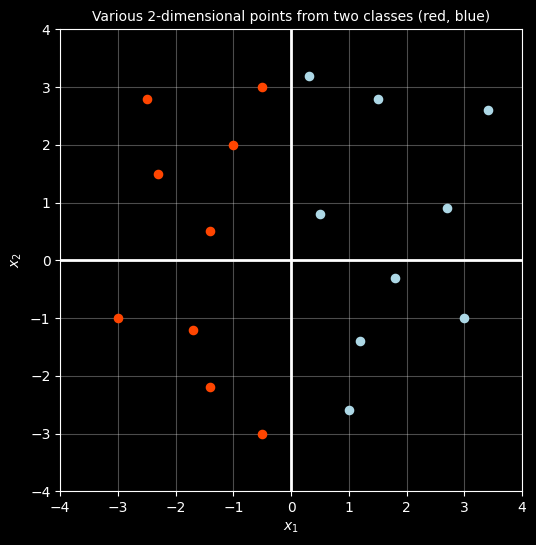

In [2]:
# Example points: teal in Q1 & Q4 (x1>0), red in Q2 & Q3 (x1<0)
blue_pts = np.array([
    [ 0.3,  3.2],   # Q1 - POINT A
    [1.5, 2.8],
    [ 3.4,  2.6],   # Q1
    [ 1.0, -2.6],   # Q4
    [ 3.0, -1.0],   # Q4
    [0.5, 0.8],
    [1.2, -1.4],
    [2.7, 0.9],
    [1.8, -0.3]
])

red_pts = np.array([
    [-1.0,  2.0],   # Q2 - POINT A
    [-0.5, 3.0],
    [-2.3,  1.5],   # Q2
    [-1.7, -1.2],   # Q3
    [-1.4, -2.2],   # Q3
    [-3.0, -1.0],   # Q3
    [-0.5, -3],
    [-1.4, 0.5],
    [-2.5, 2.8]
])

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(6, 6))

    # plot points
    ax.scatter(blue_pts[:,0], blue_pts[:,1], s=35, color="lightblue", zorder=3)
    ax.scatter(red_pts[:,0],  red_pts[:,1],  s=35, color="orangered", zorder=3)
    
    # pot the axes + grid
    ax.axhline(0, color="white", linewidth=2)
    ax.axvline(0, color="white", linewidth=2)
    #ax.text(0.1, 3.6, r"decision boundary", color="white", fontsize=10)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)

    # add labels
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"Various 2-dimensional points from two classes (red, blue)", fontsize="10")

plt.show()


In this example the vertical Y-Axis acts as a dividing line between these two sets of points, this line is called the **decision boundary**. The challenge of linear classification, is to find the **decision boundary** that separates a set of points from different classes.

In this next cell, the decision boundary is coloured yellow (there are other decision boundaries, but let's use the Y-Axis for the moment. We also add another vector, $W$ which is perpendicular to the decision boundary - we colour this pink. We also visualise the vector representation of each point by drawing an arrow from (0,0) to the point itself - these are each points vectors. Finally, we compute the dot product of $W$ against the vector for each of the blue and red points</p>

What's intersting is that for every blue point, the dot product with it and $W$ is positive and for every red point it's negative. This observation holds the key to finding the decision boundary. Specifically - <p>

**If we can find a vector $W$ whose dot product with all vectors of one class is positive and whose dot product with vectors of another class is negative, then the line perpendicular to this vector is the decision boundary that perfectly separates the two points into their distinct classes.**

In classical Machine Learning, given a set of training points from different classes, an algorithm searches for a weights vector $W$ that satisfies the above constraint. One such algortihm, which is discussed next is the **Perceptron**

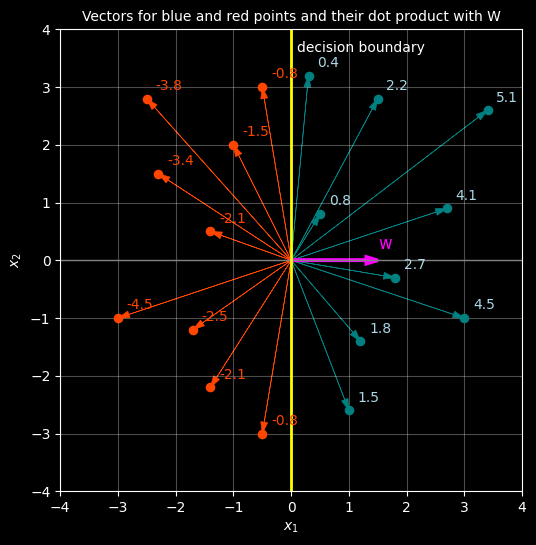

In [3]:
#
# NOTE
# Run the previous cell first
#

show_vector_lines = True
show_dot_products = True


# identify a wieghts vecgor for illustration
w = np.array([1.5, 0.0])

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(6, 6))

    # plot points
    ax.scatter(blue_pts[:,0], blue_pts[:,1], s=35, color="teal", zorder=3)
    ax.scatter(red_pts[:,0],  red_pts[:,1],  s=35, color="orangered", zorder=3)
    
    # axes + grid
    ax.axhline(0, color="grey", linewidth=1)
    ax.axvline(0, color="yellow", linewidth=2)
 
    ax.text(0.1, 3.6, r"decision boundary", color="white", fontsize=10)
    
    # arrows from origin to each point
    if show_vector_lines:
        for pt in blue_pts:
            ax.arrow(0, 0, pt[0], pt[1], length_includes_head=True, head_width=0.12, head_length=0.2, linewidth=0.5, color="teal")
        for pt in red_pts:
            ax.arrow(0, 0, pt[0], pt[1], length_includes_head=True, head_width=0.12, head_length=0.2, linewidth=0.5, color="orangered")
        # Weight vector (perpendicular to boundary)
        ax.arrow(0, 0, w[0], w[1], length_includes_head=True, head_width=0.12, head_length=0.2, linewidth=2.5, color="fuchsia")
        ax.text(1.5, 0.2, "w", color="fuchsia", fontsize=12)

    
    # Compute dot product of each point with W, the vecror perpendicular to the Y-Axis decision boundary
    if show_dot_products:
        teal_scores = blue_pts @ w
        red_scores = red_pts @ w
        for x, s in zip(blue_pts, teal_scores):
            ax.text(x[0] + 0.15, x[1] + 0.15, f"{s:.1f}", color="lightblue", fontsize=10)
        for x, s in zip(red_pts, red_scores):
            ax.text(x[0] + 0.15, x[1] + 0.15, f"{s:.1f}", color="orangered", fontsize=10)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"Vectors for blue and red points and their dot product with W", fontsize="10")

plt.show()

## Perceptron Algorithm
The perceptron algorithm is a classic approach to finding a decision boundary that separates a set of points (as long as they are linearly separable).

In an example with vectors of two dimensions and from two classes, those from one class are labelled as +1 and those from the other class as -1. A weights vector $W$ is initialised with zero (or near zero) values. The algorithm finds a solution through an iterative process of adjustment, updating the values of $W$ each time until the decision boundary correctly separates the sets of points (recall that the decision boundary is perpendicular to $W$).

Upon each iteration, the algorithm calculates the dot product between $W$ and each vector and then compares the result to the label (+1 or -1) of that vector. If the sign of the dot product matches the sign of the label, that vector is correctly classified. If all vectors are correctly classified, the algorithm stops and the current $W$ is the solution. Otherwise, the values of $W$ are updated by adding the misclassified vector (scaled by its label) to $W$.

This continues until the algorithm finds values for $W$ that give successful matches for all vector labels. The decision boundary is then perpendicular to that $W$ vector.

Note that the perceptron is not guaranteed to find the *best* solution, but if the points are linearly separable it is guaranteed to find *a* solution.

#### Key Perceptron functions
These two functions implement the core of the Perceptron algorithm. The first evaluates the current weights vector $W$ against each vector $x$ to see if $W$ correctly classifies x. The second updated $W$ in the case of an incorrect classification.

In [4]:
import numpy as np

def evaluate(W, x):
    """
    Calculate the dot product of W and point x.
    Return a score of 1 if the result is positive, otherwise return -1.
    """
    dot_prod = np.dot(W, x)
    return 1 if dot_prod >= 0 else -1

def update(w, x, y_label, learning_rate=0.1):
    """
    Update W by adding the misclassified vector scaled by its label.
    Returns the updated W.
    """
    w = w + learning_rate * y_label * x
    return w

#### Helper functions
These log the results of the current iteration and plot the current decision boundary and Weights vector.

In [5]:
def print_status(epoch, W, predictions):
    """Print the classification results for a given epoch."""
    mistakes = [(p, yi) for p, yi in zip(predictions, y) if p != yi]
    
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1}")
    print(f"{'='*70}")
    print(f"Weight vector: W = {W}")
    print(f"Total misclassifications: {len(mistakes)}\n")

    print(f"{'Idx':<5} {'Point':<20} {'Actual':<10} {'Predicted':<10} {'Dot Prod':<12} {'Status':<10}")
    print("-" * 70)
    for idx, (xi, yi, pred) in enumerate(zip(X, y, predictions)):
        actual_label  = "blue" if yi   ==  1 else "red"
        pred_label    = "blue" if pred ==  1 else "red"
        dot_prod      = np.dot(W, xi)
        status        = "✓ CORRECT" if pred == yi else "✗ WRONG"
        print(f"{idx:<5} {str(xi):<20} {actual_label:<10} {pred_label:<10} {dot_prod:<12.3f} {status:<10}")

    if not mistakes:
        print("\n✓ NO MISCLASSIFICATIONS - CONVERGED!")


def plot_decision_boundary(W, epoch):
    """Plot the data points, decision boundary and weight vector for a given W."""
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(5, 5))

        # Plot points
        ax.scatter(blue_pts[:, 0], blue_pts[:, 1], s=25, color="lightblue", zorder=3)
        ax.scatter(red_pts[:, 0],  red_pts[:, 1],  s=25, color="orangered", zorder=3)

        # Decision boundary: W^T x = 0
        x_range = np.linspace(-4, 4, 100)
        if abs(W[1]) > 0.01:
            x2_boundary = -(W[0] / W[1]) * x_range
            ax.plot(x_range, x2_boundary, color="yellow", linewidth=2)
        else:
            ax.axvline(0, color="yellow", linewidth=2)

        # Weight vector
        ax.arrow(0, 0, W[0], W[1],
                 length_includes_head=True,
                 head_width=0.12, head_length=0.2,
                 linewidth=2, color="fuchsia")

        # Axes and grid
        ax.axhline(0, color="grey", linewidth=1)
        ax.axvline(0, color="grey", linewidth=1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(r"$x_1$", fontsize=9)
        ax.set_ylabel(r"$x_2$", fontsize=9)
        ax.set_title(f"Epoch {epoch + 1}: W = {W}", fontsize=10)

        plt.tight_layout()
        plt.show()

#### Training loop
The training loop iterates through all points in $X$, evaluating each one against the current $W$. If a point is misclassified, $W$ is updated before moving on to the next point. One full pass through all points is called an **epoch**.

At the end of each epoch we check whether all points are correctly classified. If so, the algorithm has converged and we stop. If not, we run another epoch with the updated $W$. 


EPOCH 1
Weight vector: W = [0.34 0.22]
Total misclassifications: 3

Idx   Point                Actual     Predicted  Dot Prod     Status    
----------------------------------------------------------------------
0     [0.6 3.2]            blue       blue       0.908        ✓ CORRECT 
1     [1.5 2.8]            blue       blue       1.126        ✓ CORRECT 
2     [3.4 2.6]            blue       blue       1.728        ✓ CORRECT 
3     [ 1.  -2.6]          blue       blue       -0.232       ✓ CORRECT 
4     [ 3. -1.]            blue       blue       0.800        ✓ CORRECT 
5     [0.5 0.8]            blue       blue       0.346        ✓ CORRECT 
6     [ 1.2 -1.4]          blue       blue       0.100        ✓ CORRECT 
7     [2.7 0.9]            blue       blue       1.116        ✓ CORRECT 
8     [ 1.8 -0.3]          blue       blue       0.546        ✓ CORRECT 
9     [-1.  2.]            red        blue       0.100        ✗ WRONG   
10    [-0.5  3. ]          red        red        0.490   

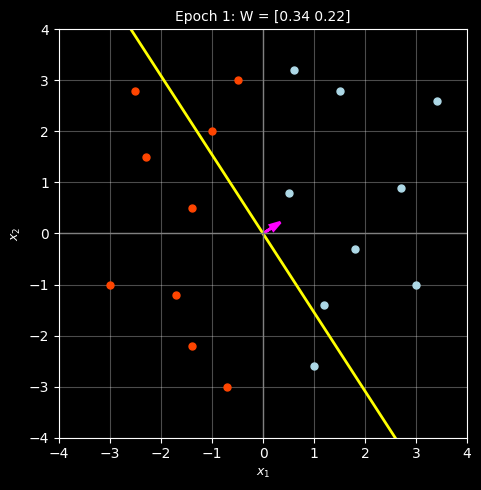


EPOCH 2
Weight vector: W = [ 0.44 -0.04]
Total misclassifications: 1

Idx   Point                Actual     Predicted  Dot Prod     Status    
----------------------------------------------------------------------
0     [0.6 3.2]            blue       blue       0.136        ✓ CORRECT 
1     [1.5 2.8]            blue       blue       0.548        ✓ CORRECT 
2     [3.4 2.6]            blue       blue       1.392        ✓ CORRECT 
3     [ 1.  -2.6]          blue       red        0.544        ✗ WRONG   
4     [ 3. -1.]            blue       blue       1.360        ✓ CORRECT 
5     [0.5 0.8]            blue       blue       0.188        ✓ CORRECT 
6     [ 1.2 -1.4]          blue       blue       0.584        ✓ CORRECT 
7     [2.7 0.9]            blue       blue       1.152        ✓ CORRECT 
8     [ 1.8 -0.3]          blue       blue       0.804        ✓ CORRECT 
9     [-1.  2.]            red        red        -0.520       ✓ CORRECT 
10    [-0.5  3. ]          red        red        -0.340

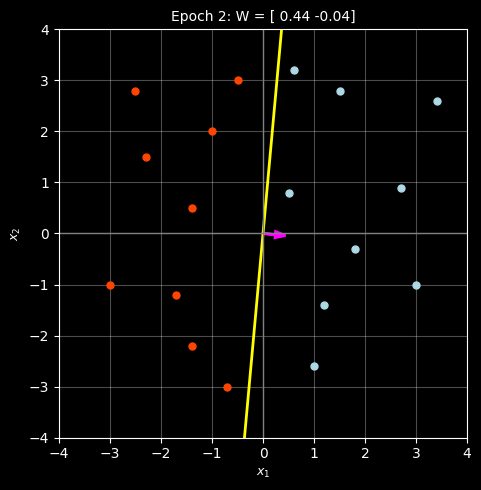


EPOCH 3
Weight vector: W = [ 0.44 -0.04]
Total misclassifications: 0

Idx   Point                Actual     Predicted  Dot Prod     Status    
----------------------------------------------------------------------
0     [0.6 3.2]            blue       blue       0.136        ✓ CORRECT 
1     [1.5 2.8]            blue       blue       0.548        ✓ CORRECT 
2     [3.4 2.6]            blue       blue       1.392        ✓ CORRECT 
3     [ 1.  -2.6]          blue       blue       0.544        ✓ CORRECT 
4     [ 3. -1.]            blue       blue       1.360        ✓ CORRECT 
5     [0.5 0.8]            blue       blue       0.188        ✓ CORRECT 
6     [ 1.2 -1.4]          blue       blue       0.584        ✓ CORRECT 
7     [2.7 0.9]            blue       blue       1.152        ✓ CORRECT 
8     [ 1.8 -0.3]          blue       blue       0.804        ✓ CORRECT 
9     [-1.  2.]            red        red        -0.520       ✓ CORRECT 
10    [-0.5  3. ]          red        red        -0.340

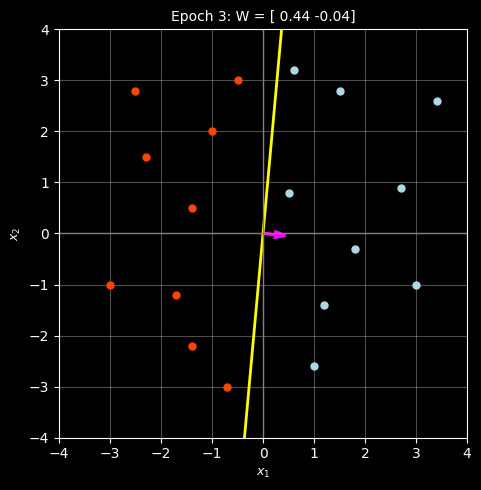


Converged after 3 epochs!
Final W: [ 0.44 -0.04]


In [6]:
# Data points - one blue and one red
blue_pts = np.array([
    [ 0.6,  3.2],
    [1.5, 2.8],
    [ 3.4,  2.6],
    [ 1.0, -2.6],
    [ 3.0, -1.0],
    [0.5, 0.8],
    [1.2, -1.4],
    [2.7, 0.9],
    [1.8, -0.3]
])
red_pts = np.array([
    [-1.0,  2.0],
    [-0.5, 3.0],
    [-2.3,  1.5],
    [-1.7, -1.2],
    [-1.4, -2.2],
    [-3.0, -1.0],
    [-0.7, -3],
    [-1.4, 0.5],
    [-2.5, 2.8]
])

# Combine points into a single matrix and create corresponding labels
X = np.vstack([blue_pts, red_pts])
y = np.hstack([np.ones(len(blue_pts)), -np.ones(len(red_pts))])

# Initialise W as a zero vector with the same number of dimensions as our points
W = np.zeros(2)

# Training loop
for epoch in range(10):
    predictions = []
    for xi, yi in zip(X, y):
        pred = evaluate(W, xi)
        predictions.append(pred)
        if pred != yi:
            W = update(W, xi, yi)

    print_status(epoch, W, predictions)
    plot_decision_boundary(W, epoch)

    if all(p == yi for p, yi in zip(predictions, y)):
        print(f"\nConverged after {epoch + 1} epochs!")
        print(f"Final W: {W}")
        break